# Clustering with K-Means — Solutions

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/rework/solutions/05_Clustering_KMeans_solutions.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Important:** Try the exercises in `demos/05_Clustering_KMeans.ipynb` yourself first. The struggle is where the learning happens.

These are *reference* solutions with short explanations. Your own working solution may look different and still be correct.

In [1]:
# === COURSE SETUP — run this cell first! ===
%pip install -q numpy pandas matplotlib seaborn scikit-learn

import os, urllib.request
DATA_URL = "https://raw.githubusercontent.com/LuWidme/uk259/rework/datasets/"
for folder in ("datasets", os.path.join("..", "datasets")):
    os.makedirs(folder, exist_ok=True)
    for fname in ['titanic.csv', 'melb_data.csv', 'Company_data.csv']:
        path = os.path.join(folder, fname)
        if not os.path.exists(path):
            urllib.request.urlretrieve(DATA_URL + fname, path)
print("Setup complete — you are ready to go!")

Note: you may need to restart the kernel to use updated packages.
Setup complete — you are ready to go!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
np.random.seed(42)

# Synthetic data (same idea as in the demo)
features, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Palmer Penguins — real measurements; the species label is hidden from the algorithm
penguins = sns.load_dataset('penguins')
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins = penguins.dropna(subset=feature_cols).reset_index(drop=True)
X = penguins[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)   # scale: K-Means distances need comparable units
print('Data ready:', features.shape, X_scaled.shape)

Data ready: (300, 2) (342, 4)


## Exercise 1: Implement the Elbow Method

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\minic

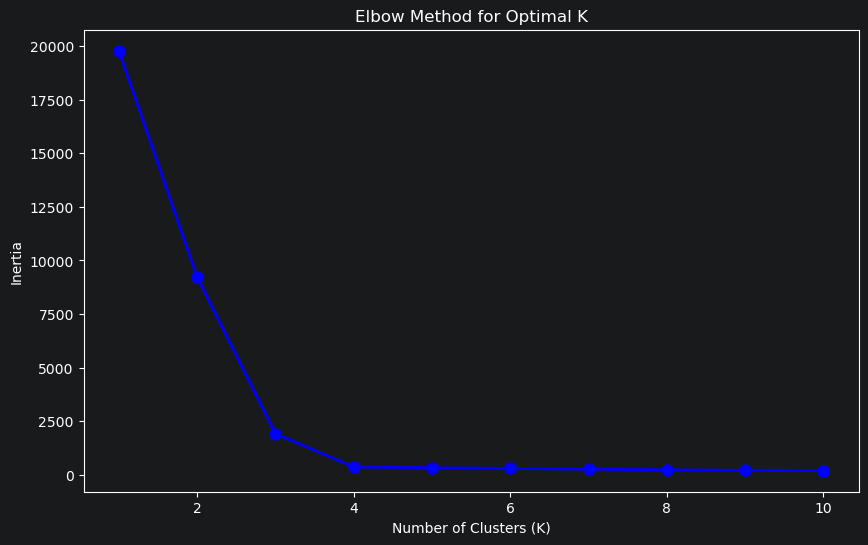

The elbow is around K=4 — adding more clusters barely lowers inertia.


In [3]:
k_values = range(1, 11)
inertias = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()
print('The elbow is around K=4 — adding more clusters barely lowers inertia.')

## Exercise 2: Discovering Penguin Groups

Main exercise: find a reasonable K with the elbow method on the **scaled** penguin data, cluster, visualise, then reveal the true species.

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\minic

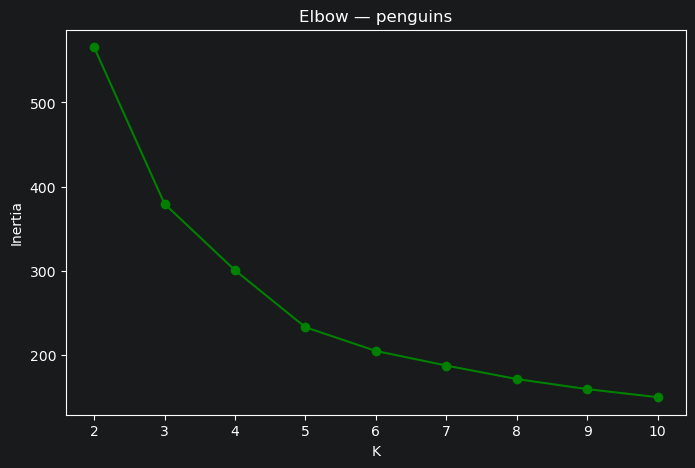

The kink is gentle: K=3 matches the 3 species, but K=2 (big vs. small penguins) is also defensible.


In [4]:
# Elbow on scaled penguin data
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertias, 'go-')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow — penguins')
plt.show()
print('The kink is gentle: K=3 matches the 3 species, but K=2 (big vs. small penguins) is also defensible.')

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


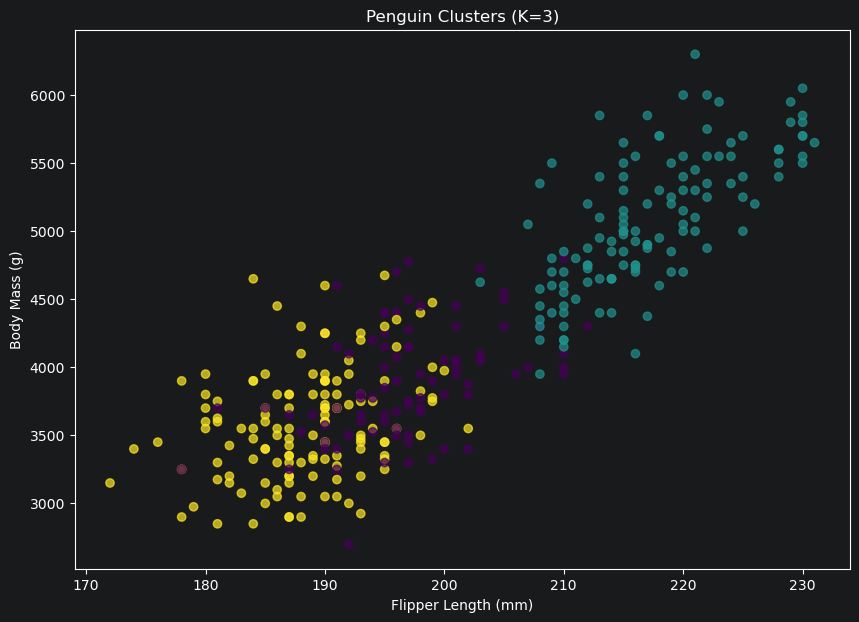

True species  Adelie  Chinstrap  Gentoo
Cluster                                
0                 24         63       0
1                  0          0     123
2                127          5       0


In [5]:
optimal_k = 3   # 3 species; the elbow is soft, so K=2 would also be reasonable
kmeans_penguins = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
penguin_labels = kmeans_penguins.fit_predict(X_scaled)

# Visualise a 2D slice of the 4D data, coloured by cluster
plt.figure(figsize=(10, 7))
plt.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'],
            c=penguin_labels, cmap='viridis', alpha=0.7)
plt.xlabel('Flipper Length (mm)'); plt.ylabel('Body Mass (g)')
plt.title('Penguin Clusters (K=3)'); plt.show()

# Reveal: compare clusters to the true species (never seen by K-Means)
print(pd.crosstab(penguin_labels, penguins['species'],
                  rownames=['Cluster'], colnames=['True species']))

## Bonus: K-Means from Scratch

### Task 1: Initialize Cluster Centers

In [6]:
def initialize_centers(data, k):
    n_samples = data.shape[0]
    indices = np.random.choice(n_samples, k, replace=False)
    return data[indices]

centers = initialize_centers(features, 4)
print('Initial centers:\n', centers)

Initial centers:
 [[ 4.16838703  2.65285136]
 [-6.78339069 -6.46855853]
 [ 4.86467233  1.47501007]
 [ 3.68683604  2.49841257]]


### Task 2: Assign Points to Nearest Cluster

In [7]:
def assign_clusters(data, centers):
    distances = pairwise_distances(data, centers)
    return np.argmin(distances, axis=1)

labels = assign_clusters(features, centers)
print('First 10 labels:', labels[:10])

First 10 labels: [1 1 3 1 1 1 0 1 3 3]


### Task 3: Update Cluster Centers

In [8]:
def update_centers(data, labels, k):
    n_features = data.shape[1]
    new_centers = np.zeros((k, n_features))
    for i in range(k):
        points = data[labels == i]
        if len(points) > 0:
            new_centers[i] = points.mean(axis=0)
    return new_centers

centers = update_centers(features, labels, 4)
print('Updated centers:\n', centers)

Updated centers:
 [[ 4.65809498  2.76131044]
 [-7.52330059 -3.3611506 ]
 [ 5.17937853  1.54721684]
 [-4.0225071   7.71112831]]


### Task 4: Complete K-Means Algorithm

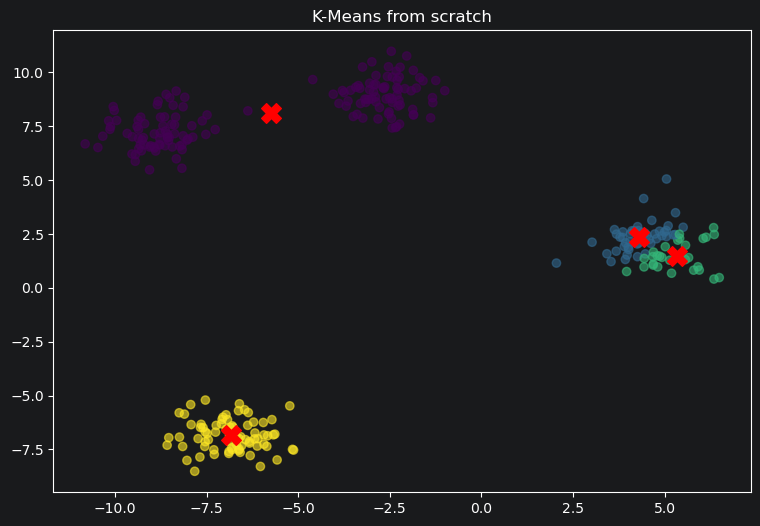

In [9]:
def k_means(data, k, max_iter=100, tolerance=1e-4):
    centers = initialize_centers(data, k)
    for _ in range(max_iter):
        labels = assign_clusters(data, centers)
        new_centers = update_centers(data, labels, k)
        # stop if centers have not moved significantly
        if np.linalg.norm(new_centers - centers) < tolerance:
            break
        centers = new_centers
    return labels, centers

labels, centers = k_means(features, 4)
plt.figure(figsize=(9,6))
plt.scatter(features[:,0], features[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centers[:,0], centers[:,1], c='red', marker='X', s=200)
plt.title('K-Means from scratch'); plt.show()